In [1]:
import numpy as np
import matplotlib
# matplotlib.use("Agg")   # backend non interactif
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, filtfilt,freqs

import scipy.signal as signal

In [2]:
fs = 1000000
T = 1.0

N = int(fs * T)

In [3]:
f_1 = 1000

phi_1 = np.pi/4

t_1 = np.arange(0, 1, 1/fs)

signal_1 = np.sin(2*np.pi*f_1*t_1 + phi_1)

In [4]:
signal_1

array([0.70710678, 0.71153568, 0.71593648, ..., 0.69365331, 0.69816542,
       0.70264997])

Text(0, 0.5, 'Time s')

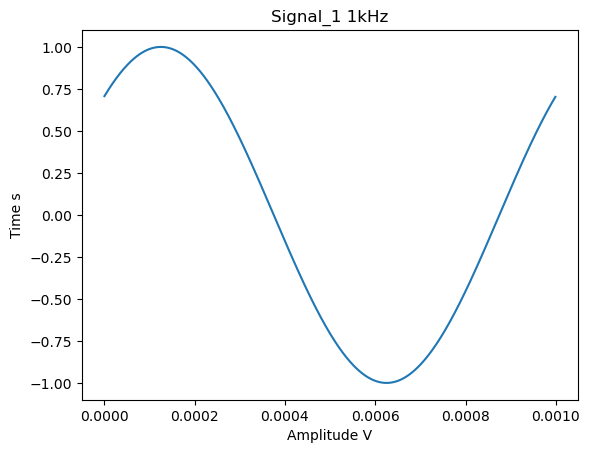

In [5]:
plt.figure()
plt.plot(t_1[0:1000], signal_1[0:1000])
plt.title("Signal_1 1kHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

In [6]:
f_2 = 7000
phi_2 = np.pi/3
t_2 = np.arange(0, 1, 1/fs)

signal_2 = np.cos(2*np.pi*f_2*t_2 + phi_2)

Text(0, 0.5, 'Time s')

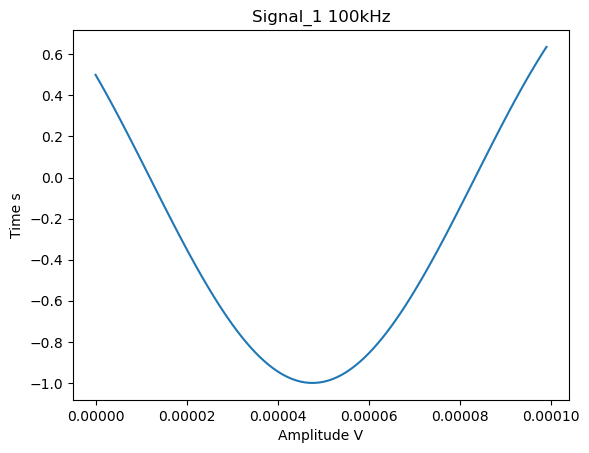

In [7]:
plt.figure()
plt.plot(t_2[0:100], signal_2[0:100])
plt.title("Signal_1 100kHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

In [8]:
signal_1.shape, signal_2.shape

((1000000,), (1000000,))

In [9]:
f_3 = 5000
phi_3 = np.pi/2
t_3 = np.arange(0, 1, 1/fs)

signal_3 = np.cos(2*np.pi*f_3*t_3 + phi_3)

Text(0, 0.5, 'Time s')

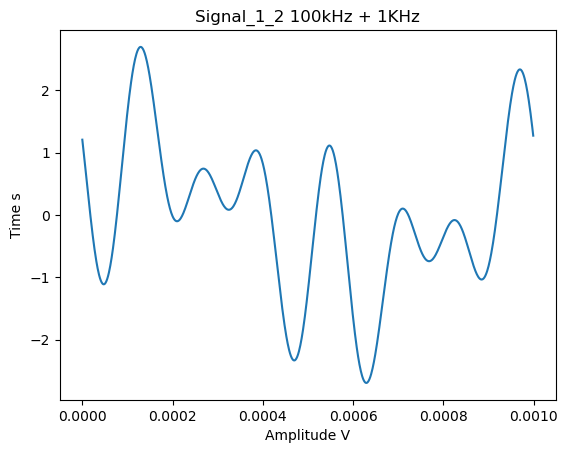

In [10]:
signal_1_2_3 = signal_1 + signal_2 + signal_3
noise = 1000*np.random.randn(len(signal_1_2_3)) *0

signal_1_2_3 = signal_1_2_3 + noise

plt.figure()
plt.plot(t_1[0:1000], signal_1_2_3[0:1000])
plt.title("Signal_1_2 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")

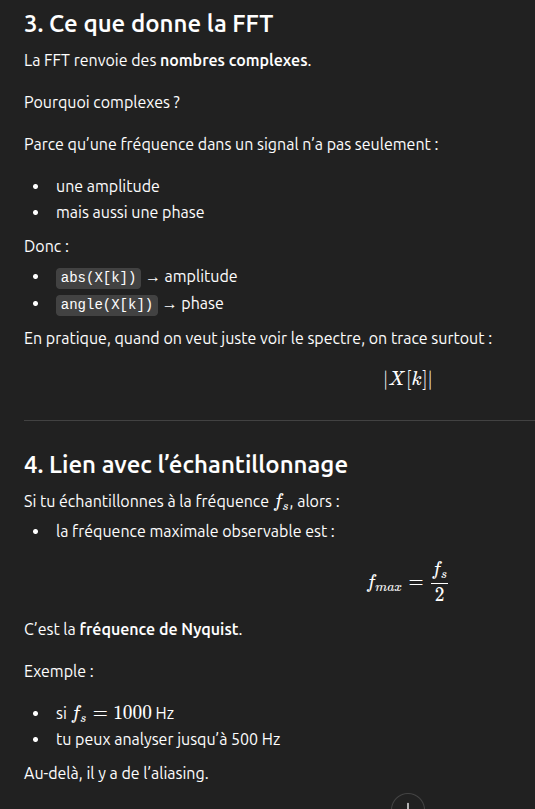
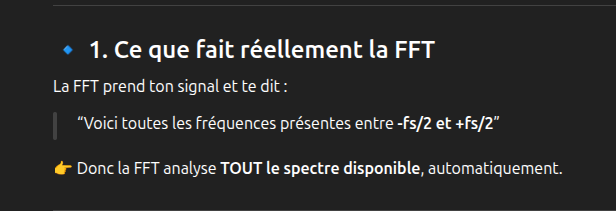
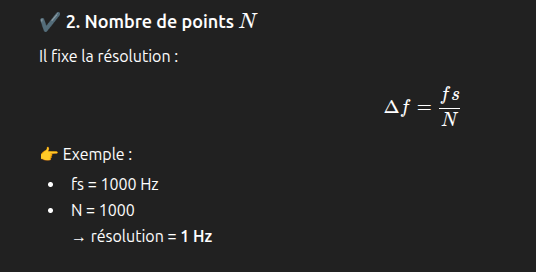

In [11]:
X = np.fft.fft(signal_1_2_3)

freq = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

phase = np.angle(X)

freq.shape, Ampl.shape, phase.shape

((1000000,), (1000000,), (1000000,))

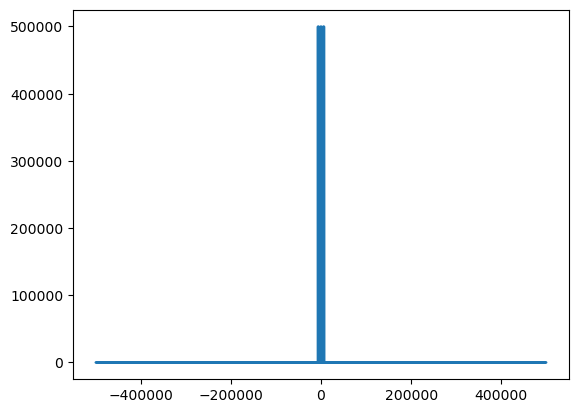

Pic à 1000.000 Hz
Pic à 5000.000 Hz
Pic à 7000.000 Hz
Pic à -7000.000 Hz
Pic à -5000.000 Hz
Pic à -1000.000 Hz


In [14]:
plt.figure()
plt.plot(freq[:], Ampl[:])
# plt.plot(freqs[:], phase[:])

peaks, properties = find_peaks(Ampl, height=10)
# plt.plot(freqs[peaks], Ampl[peaks], "rx") 
plt.show()
for p in peaks:
    print(f"Pic à {freq[p]/1:.3f} Hz")
# plt.xlim(-50000, 50000)
# plt.ylim(0, 200)

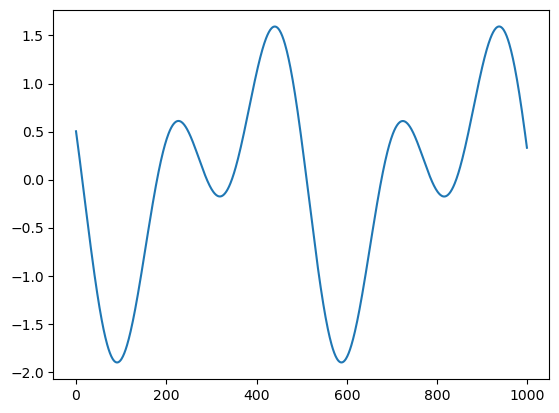

In [41]:
X_filtred = X[np.abs(freq) > 3000]
signal_filtered_freq_domain = np.real(np.fft.ifft(X_filtred))

plt.figure()
plt.plot(signal_filtered_freq_domain[:1000])
plt.show()

In [42]:
X_pf = np.fft.fft(signal_filtered_freq_domain)

freq_pf = np.fft.fftfreq(N, d=1/fs)

Ampl_pf = np.abs(X_pf)


freq_pf.shape, Ampl_pf.shape

((1000000,), (993999,))

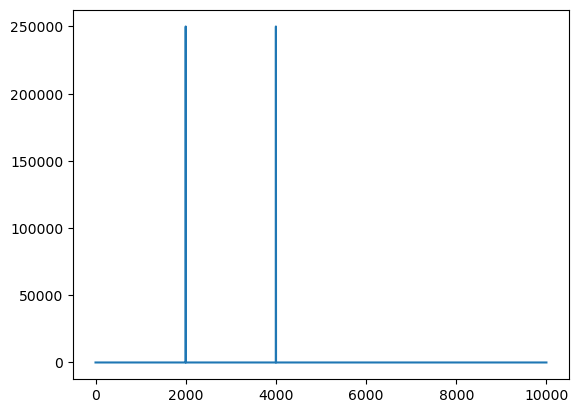

In [46]:
plt.figure()
plt.plot(freq_pf[:10000], Ampl_pf[:10000])
plt.show()

# Hightpass

In [159]:
cutoff = 6000

Wn = cutoff/(fs/2)

# Création du filtre
b, a = butter(N=8, Wn=Wn, btype='highpass')
w, h = signal.freqs(b ,a)
# Application du filtre
signal_filtered = filtfilt(b, a, signal_1_2_3)

In [160]:
b.shape, a.shape, signal_filtered.shape, Wn

((9,), (9,), (1000000,), 0.012)

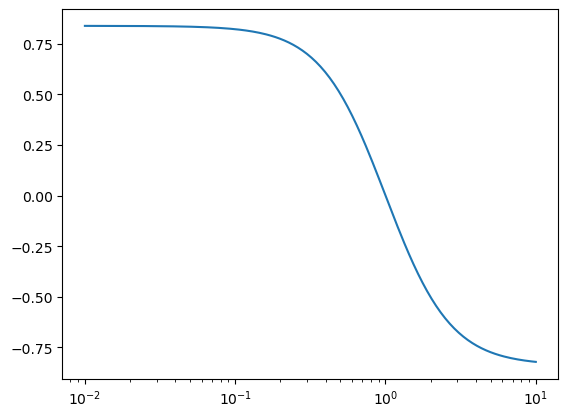

In [161]:
plt.figure()
# plt.plot(w, 20*np.log10(np.abs(h)))
plt.semilogx(w, 20 * np.log10(abs(h)))
plt.show()

In [ ]:
plt.figure()
plt.plot()
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

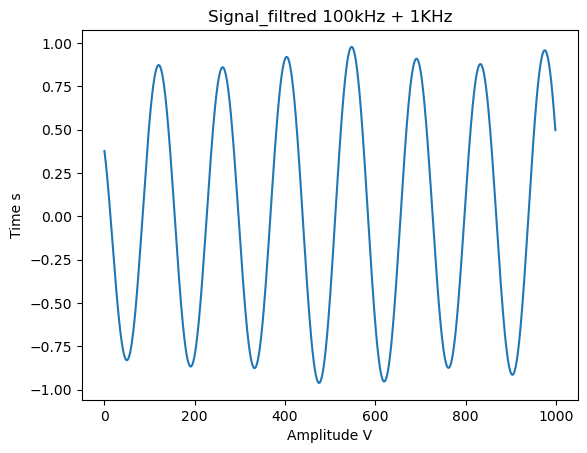

In [150]:
X = np.fft.fft(signal_filtered)

freqs = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

plt.figure()
plt.plot(signal_filtered[0:1000])
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

# bandpass

In [140]:
f_low = 3000
f_high = 6000

Wn = [f_low/(fs/2), f_high/(fs/2)]

# Création du filtre
b, a = butter(N=4, Wn=Wn, btype='bandpass')
w, h = signal.freqs(b ,a)
# Application du filtre
signal_filtered = filtfilt(b, a, signal_1_2_3)

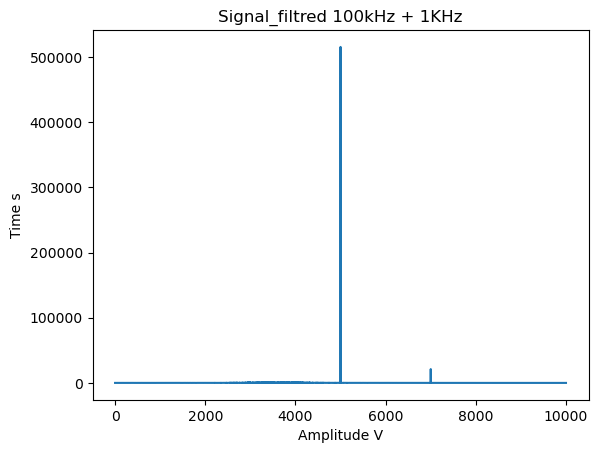

In [141]:
X = np.fft.fft(signal_filtered)

freqs = np.fft.fftfreq(N, d=1/fs)

Ampl = np.abs(X)

plt.figure()
plt.plot(freqs[0:10000], Ampl[0:10000])
plt.title("Signal_filtred 100kHz + 1KHz")
plt.xlabel("Amplitude V")
plt.ylabel("Time s")
plt.show()

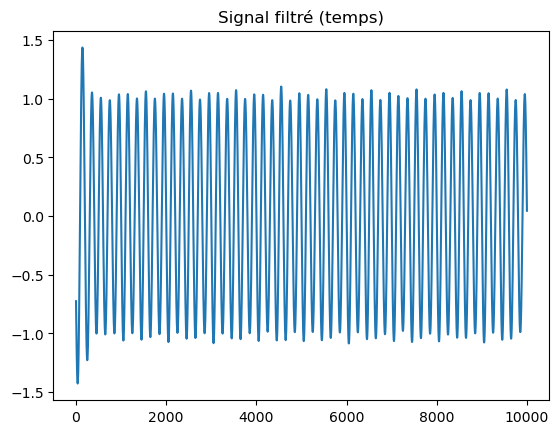

In [144]:
plt.plot(signal_filtered[:10000])
plt.title("Signal filtré (temps)")
plt.show()